# AnimalCLEF 2026 - Data Exploration

This notebook explores the competition dataset and helps understand the task.

In [6]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

%matplotlib inline
sns.set_style('darkgrid')

## Load Competition Metadata

In [7]:
# Load metadata
metadata = pd.read_csv('../data/raw/metadata.csv')
print(f"Total images: {len(metadata)}")
print(f"Columns: {metadata.columns.tolist()}")
metadata.head()

Total images: 15483
Columns: ['image_id', 'identity', 'path', 'date', 'orientation', 'species', 'split', 'dataset']


,image_id,identity,path,date,orientation,species,split,dataset
0,0,LynxID2025_lynx_37,images/LynxID2025/train/37/000f9ee1aad063a4485...,NaN,right,lynx,train,LynxID2025
1,1,LynxID2025_lynx_37,images/LynxID2025/train/37/0020edb6689e9f78462...,NaN,left,lynx,train,LynxID2025
2,2,LynxID2025_lynx_49,images/LynxID2025/train/49/003152e4145b5b69400...,NaN,left,lynx,train,LynxID2025
3,3,NaN,images/LynxID2025/test/003b89301c7b9f6d18f7220...,NaN,back,lynx,test,LynxID2025
4,4,LynxID2025_lynx_13,images/LynxID2025/train/13/003c3f82011e9c3f849...,NaN,right,lynx,train,LynxID2025


In [8]:
# Check for missing values
print("Missing values:")
print(metadata.isnull().sum())

Missing values:
image_id          0
identity       2409
path              0
date           4181
orientation     977
species        1388
split             0
dataset           0
dtype: int64


## Dataset Statistics

In [9]:
# Dataset distribution
if 'dataset' in metadata.columns:
    dataset_counts = metadata['dataset'].value_counts()
    print(f"Number of datasets: {len(dataset_counts)}")
    print("\nImages per dataset:")
    print(dataset_counts)

Number of datasets: 4

Images per dataset:
dataset
SeaTurtleID2022       9229
LynxID2025            3903
SalamanderID2025      2077
TexasHornedLizards     274
Name: count, dtype: int64


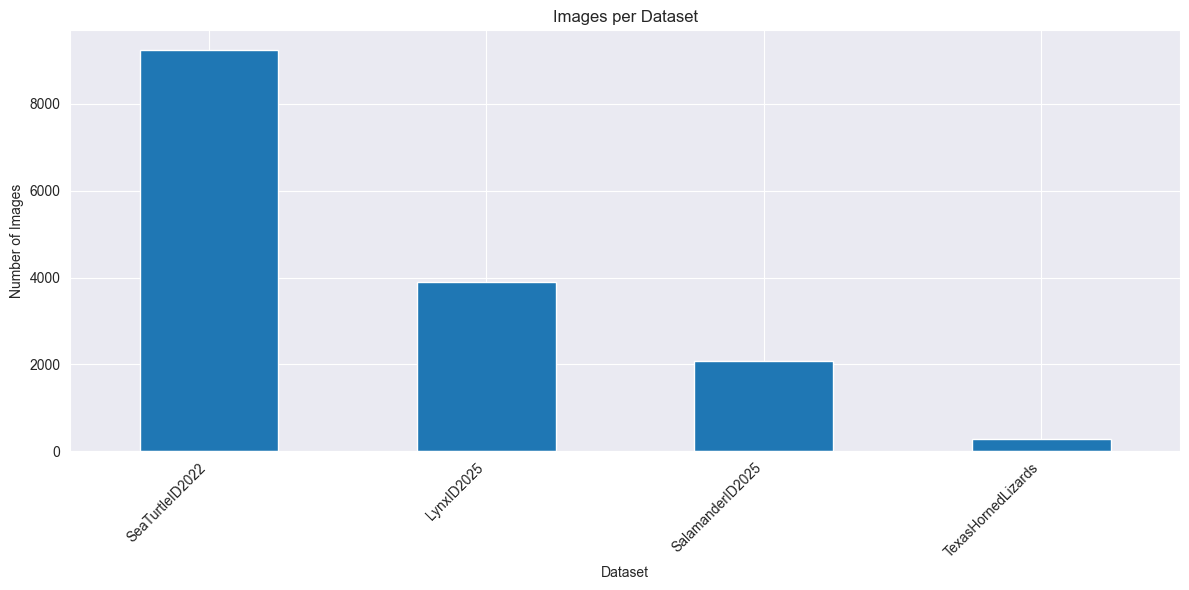

In [10]:
# Plot dataset distribution
if 'dataset' in metadata.columns:
    plt.figure(figsize=(12, 6))
    dataset_counts.plot(kind='bar')
    plt.title('Images per Dataset')
    plt.xlabel('Dataset')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [11]:
# Identity distribution
if 'identity' in metadata.columns:
    identity_counts = metadata['identity'].value_counts()
    print(f"Number of unique identities: {len(identity_counts)}")
    print(f"Images per identity (mean): {identity_counts.mean():.2f}")
    print(f"Images per identity (median): {identity_counts.median():.2f}")
    print(f"Images per identity (min): {identity_counts.min()}")
    print(f"Images per identity (max): {identity_counts.max()}")

Number of unique identities: 1102
Images per identity (mean): 11.86
Images per identity (median): 4.00
Images per identity (min): 1
Images per identity (max): 353


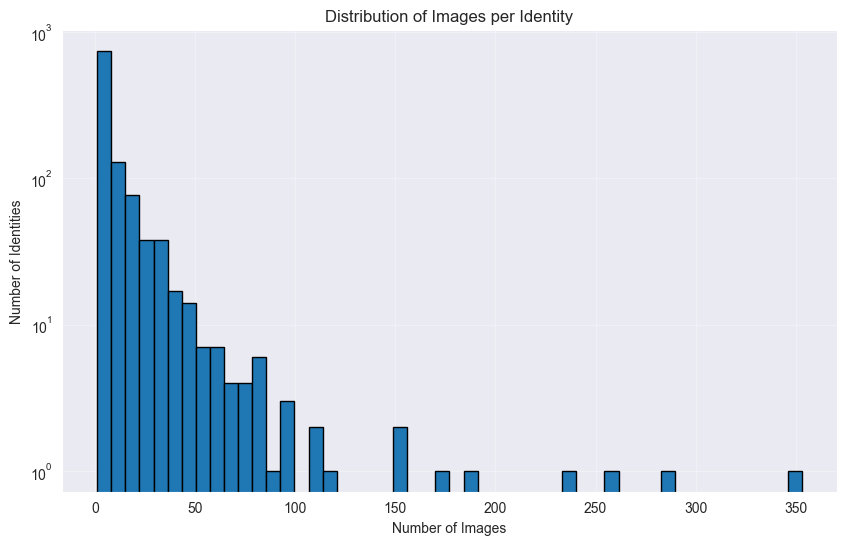

In [12]:
# Plot identity distribution
if 'identity' in metadata.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(identity_counts, bins=50, edgecolor='black')
    plt.title('Distribution of Images per Identity')
    plt.xlabel('Number of Images')
    plt.ylabel('Number of Identities')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.show()

## Visualize Sample Images

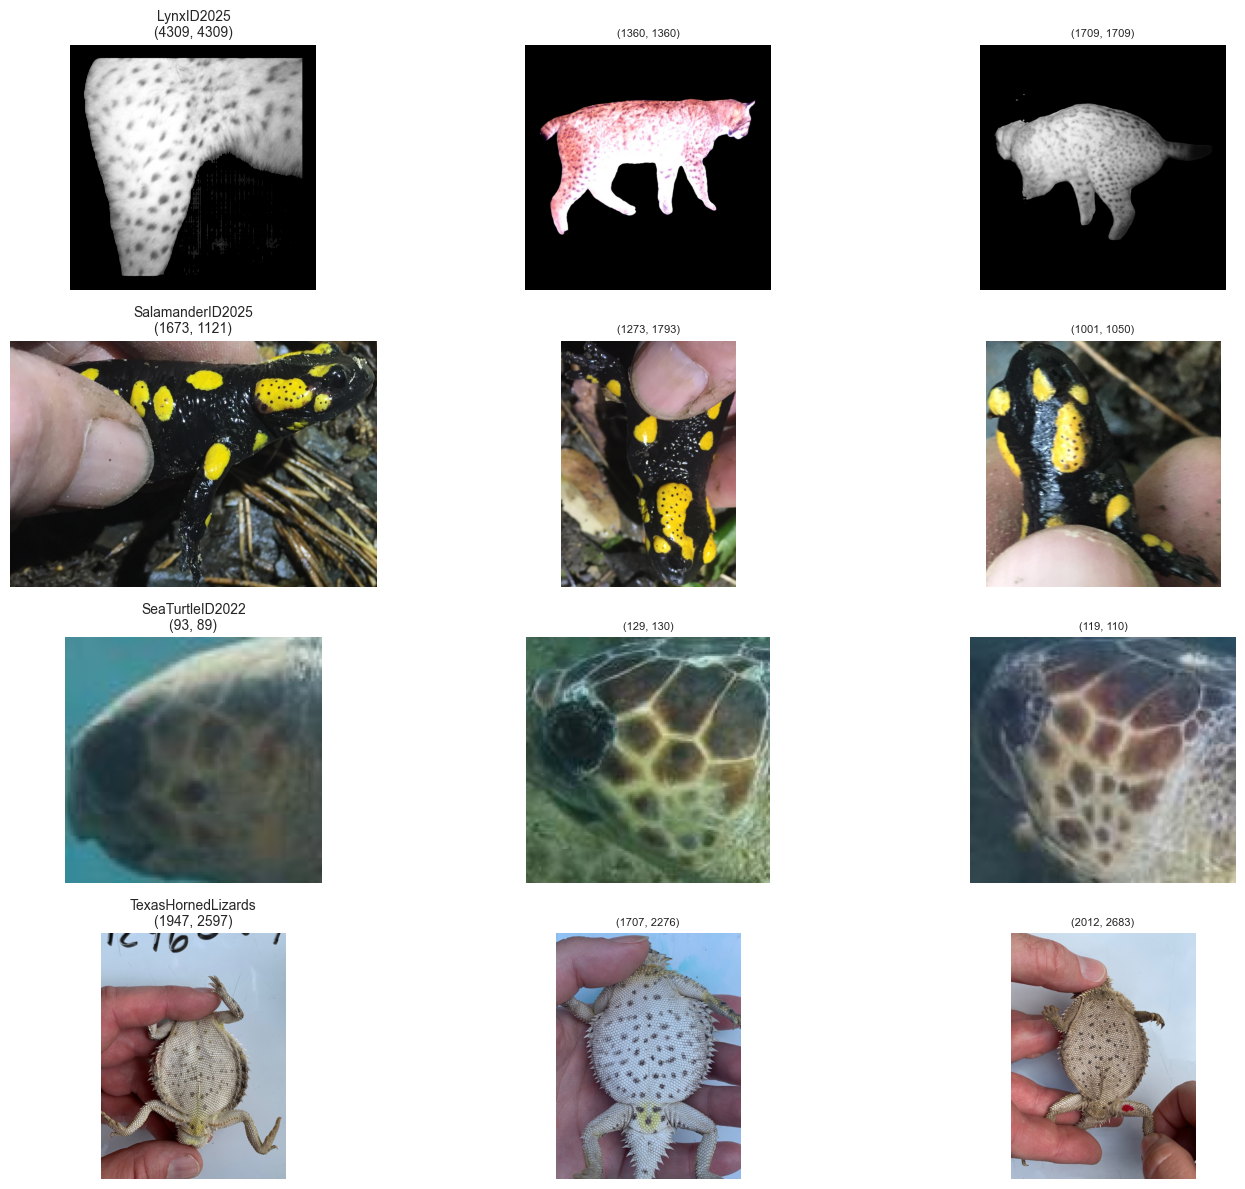

In [13]:
# Visualize random samples from each dataset
def plot_sample_images(metadata, num_samples=3):
    if 'dataset' in metadata.columns:
        datasets = metadata['dataset'].unique()
        
        fig, axes = plt.subplots(len(datasets), num_samples, figsize=(15, len(datasets) * 3))
        
        for i, dataset_name in enumerate(datasets):
            dataset_images = metadata[metadata['dataset'] == dataset_name].sample(n=min(num_samples, len(metadata[metadata['dataset'] == dataset_name])))
            
            for j, (_, row) in enumerate(dataset_images.iterrows()):
                img_path = Path('../data/raw') / row['path']
                if img_path.exists():
                    img = Image.open(img_path)
                    
                    if len(datasets) == 1:
                        ax = axes[j]
                    else:
                        ax = axes[i, j]
                    
                    ax.imshow(img)
                    ax.axis('off')
                    if j == 0:
                        ax.set_title(f"{dataset_name}\n{img.size}", fontsize=10)
                    else:
                        ax.set_title(f"{img.size}", fontsize=8)
        
        plt.tight_layout()
        plt.show()

plot_sample_images(metadata, num_samples=3)

## Check Image Sizes

In [14]:
# Sample images to check size distribution
def get_image_sizes(metadata, num_samples=100):
    sizes = []
    sample_rows = metadata.sample(n=min(num_samples, len(metadata)))
    
    for _, row in sample_rows.iterrows():
        img_path = Path('../data/raw') / row['path']
        if img_path.exists():
            img = Image.open(img_path)
            sizes.append(img.size)
    
    return sizes

image_sizes = get_image_sizes(metadata, num_samples=200)
widths = [s[0] for s in image_sizes]
heights = [s[1] for s in image_sizes]

print(f"Width - Mean: {np.mean(widths):.0f}, Median: {np.median(widths):.0f}")
print(f"Height - Mean: {np.mean(heights):.0f}, Median: {np.median(heights):.0f}")

Width - Mean: 646, Median: 392
Height - Mean: 705, Median: 356


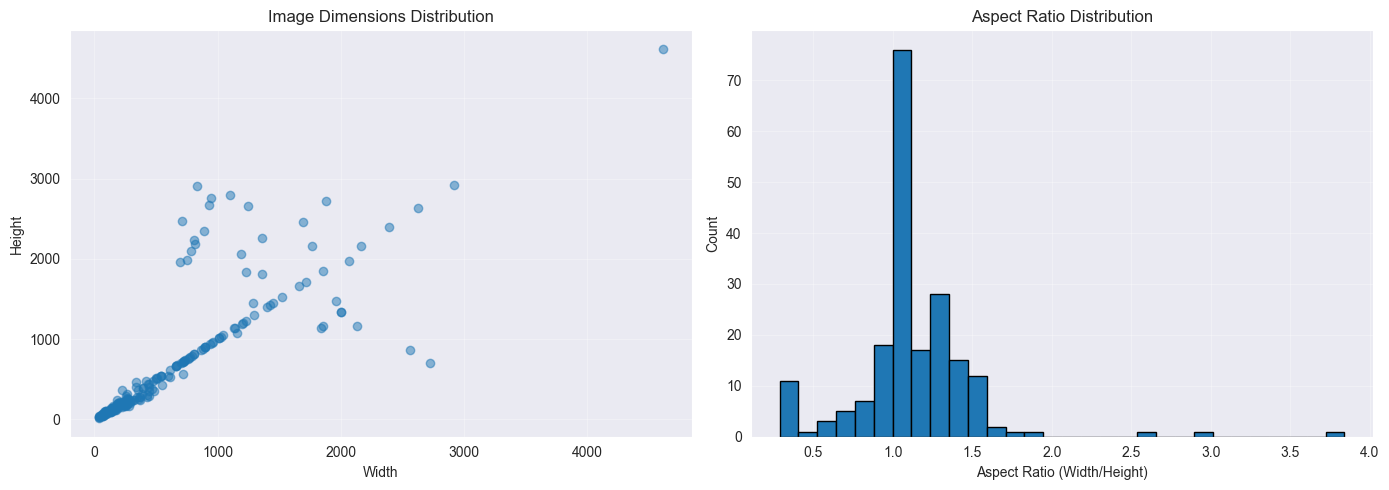

In [15]:
# Plot image size distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(widths, heights, alpha=0.5)
axes[0].set_xlabel('Width')
axes[0].set_ylabel('Height')
axes[0].set_title('Image Dimensions Distribution')
axes[0].grid(True, alpha=0.3)

aspect_ratios = [w/h for w, h in zip(widths, heights)]
axes[1].hist(aspect_ratios, bins=30, edgecolor='black')
axes[1].set_xlabel('Aspect Ratio (Width/Height)')
axes[1].set_ylabel('Count')
axes[1].set_title('Aspect Ratio Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Sample Submission Format

In [16]:
# Load sample submission
sample_submission = pd.read_csv('../data/raw/sample_submission.csv')
print(f"Submission shape: {sample_submission.shape}")
print(f"Columns: {sample_submission.columns.tolist()}")
sample_submission.head()

Submission shape: (2409, 2)
Columns: ['image_id', 'cluster']


,image_id,cluster
0,3,cluster_LynxID2025_71
1,5,cluster_LynxID2025_0
2,12,cluster_LynxID2025_72
3,13,cluster_LynxID2025_73
4,18,cluster_LynxID2025_74


## Next Steps

### 1. Baseline Approach
- Try **MegaDescriptor** foundation model (see examples above)
- Extract features from train/test images
- Use cosine similarity for matching

### 2. Data Strategy
- **Augmentation**: Design augmentation strategy based on image characteristics
- **Wildlife Datasets**: Use additional datasets for pre-training:
  - `SeaTurtleIDHeads` for sea turtle images
  - `LeopardID2022` for big cat patterns (similar to lynx)
  - `MacaqueFaces` for facial feature learning
- **Cross-Dataset Training**: Improves generalization

### 3. Model Training
- **Train/Val Split**: Create appropriate splits (time-aware, identity-aware)
- **Metric Learning**: Implement ArcFace, CosFace, or TripletLoss
- **Fine-tuning**: Start with pre-trained model, fine-tune on competition data

### 4. Advanced Techniques
- **Ensemble**: Combine multiple models
- **Query Expansion**: Use multiple similar images for better matching
- **Re-ranking**: Post-process predictions for better accuracy

### 5. Evaluation & Submission
- Validate on local train/test split
- Generate predictions for test set
- Create submission file
- Submit to Kaggle!

---

**Useful Notebooks to Create:**
- `02_megadescriptor_baseline.ipynb` - MegaDescriptor feature extraction
- `03_training_custom_model.ipynb` - Train custom re-ID model
- `04_wildlife_datasets_training.ipynb` - Use additional datasets
- `05_submission_generation.ipynb` - Create final submission

In [17]:
# Example: Using MegaDescriptor for feature extraction
# Note: This will download the model on first use (~500MB)

print("🔥 MegaDescriptor Foundation Model")
print("=" * 60)
print("MegaDescriptor is a powerful foundation model for wildlife re-ID")
print("Pre-trained on diverse wildlife datasets")
print("\nFeatures:")
print("  • Strong baseline for wildlife re-identification")
print("  • Works across multiple species")
print("  • Can be fine-tuned for specific tasks")
print("\nUsage example:")
print("""
from wildlife_tools.features import DeepFeatures

# Initialize MegaDescriptor
model = DeepFeatures(backbone='megadescriptor-l-384')

# Extract features from images
# images should be torch.Tensor of shape [B, 3, H, W]
features = model.extract(images)

# Features are normalized embeddings ready for similarity comparison
print(f"Feature shape: {features.shape}")  # [B, embedding_dim]
""")

print("\n💡 For this competition:")
print("  1. Extract features from train/test images using MegaDescriptor")
print("  2. Compute cosine similarity between query and gallery embeddings")
print("  3. Create submission based on top-k most similar images")
print("\n  See src/models.py for implementation: load_megadescriptor_model()")

🔥 MegaDescriptor Foundation Model
MegaDescriptor is a powerful foundation model for wildlife re-ID
Pre-trained on diverse wildlife datasets

Features:
  • Strong baseline for wildlife re-identification
  • Works across multiple species
  • Can be fine-tuned for specific tasks

Usage example:

from wildlife_tools.features import DeepFeatures

# Initialize MegaDescriptor
model = DeepFeatures(backbone='megadescriptor-l-384')

# Extract features from images
# images should be torch.Tensor of shape [B, 3, H, W]
features = model.extract(images)

# Features are normalized embeddings ready for similarity comparison
print(f"Feature shape: {features.shape}")  # [B, embedding_dim]


💡 For this competition:
  1. Extract features from train/test images using MegaDescriptor
  2. Compute cosine similarity between query and gallery embeddings
  3. Create submission based on top-k most similar images

  See src/models.py for implementation: load_megadescriptor_model()


### Using MegaDescriptor (Wildlife-Tools)

The `wildlife-tools` package provides MegaDescriptor, a foundation model pre-trained on wildlife data:

In [27]:
# Quick comparison of different wildlife datasets (without downloading)
from wildlife_datasets import datasets as wildlife_datasets_module

recommended_datasets = [
    'SeaTurtleIDHeads',
    'LeopardID2022', 
    'MacaqueFaces',
    'BelugaID',
    'BalearicLizardSegmented'
]

print("🔍 Quick Dataset Comparison")
print("=" * 80)
print(f"{'Dataset':<25} {'Available':<12} {'Notes'}")
print("-" * 80)

for ds_name in recommended_datasets:
    available = "✓" if hasattr(wildlife_datasets_module, ds_name) else "✗"
    
    if available == "✓":
        notes = "Ready to download"
    else:
        notes = "Not found"
    
    print(f"{ds_name:<25} {available:<12} {notes}")

print("\n💡 To download a dataset:")
print("   wildlife_ds = load_wildlife_dataset('DatasetName', '../data/wildlife_datasets')")
print("\n💡 To use with PyTorch:")
print("   pytorch_ds = WildlifeDatasetPyTorch(wildlife_ds, transform=your_transforms)")

🔍 Quick Dataset Comparison
Dataset                   Available    Notes
--------------------------------------------------------------------------------
SeaTurtleIDHeads          ✓            Ready to download
LeopardID2022             ✓            Ready to download
MacaqueFaces              ✓            Ready to download
BelugaID                  ✓            Ready to download
BalearicLizardSegmented   ✓            Ready to download

💡 To download a dataset:
   wildlife_ds = load_wildlife_dataset('DatasetName', '../data/wildlife_datasets')

💡 To use with PyTorch:
   pytorch_ds = WildlifeDatasetPyTorch(wildlife_ds, transform=your_transforms)


In [29]:
# Download and load a wildlife dataset
from src.data_loading import load_wildlife_dataset

# Choose a dataset - MacaqueFaces is relatively small (~100MB)
dataset_name = 'BalearicLizard'

# This will download on first run, then load from cache
print(f"Loading {dataset_name}...")
print("(First run will download the dataset - this may take a few minutes)")
print("-" * 60)

try:
    wildlife_ds = load_wildlife_dataset(dataset_name, '../data/wildlife_datasets')
    print(f"✓ Dataset loaded successfully!")
except Exception as e:
    print(f"Note: To download, uncomment the line above.")
    print(f"Error: {e}")
    wildlife_ds = None

Loading BalearicLizard...
(First run will download the dataset - this may take a few minutes)
------------------------------------------------------------
DATASET BalearicLizard: DOWNLOADING STARTED.
Dataset URL: https://www.kaggle.com/datasets/roberalcaraz/baleariclizard
License(s): CC-BY-NC-SA-4.0


  0%|          | 17.0M/33.9G [00:04<1:28:38, 6.84MB/s]

User cancelled operation
DATASET BalearicLizard: EXTRACTING STARTED.
Note: To download, uncomment the line above.
Error: Extracting failed.
                Either the download was not completed or the Kaggle terms were not agreed with.
                Check https://wildlifedatasets.github.io/wildlife-datasets/downloads#baleariclizard


  0%|          | 19.0M/33.9G [00:04<2:14:49, 4.50MB/s]


### Recommended Datasets for Training

Based on the competition datasets (Lynx, Salamanders, Sea Turtles, Lizards), here are some potentially useful wildlife datasets:

**Similar Species:**
- `SeaTurtleIDHeads` - Additional sea turtle data
- `LeopardID2022` - Big cats (similar to lynx)
- `CTai` - Elephants and other animals
- `GiraffeZebraID` - Large herbivores

**General Wildlife:**
- `MacaqueFaces` - Primate faces (good for facial features)
- `BelugaID` - Marine mammals
- `HyenaID2022` - Carnivores
- `OpenCows2020` - Individual identification patterns

**Reptiles/Amphibians:**
- `FriesianCattle2017` - Pattern recognition
- `NOAARightWhale` - Distinctive markings

**Tips:**
1. Start with datasets similar to competition species
2. Use larger datasets for pre-training
3. Fine-tune on competition data
4. Mix datasets to improve generalization

In [20]:
# Example: Create a PyTorch dataset from wildlife dataset
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class WildlifeDatasetPyTorch(Dataset):
    """Wrapper to use wildlife-datasets with PyTorch"""
    
    def __init__(self, wildlife_dataset, dataset_name, base_dir='../data/wildlife_datasets', transform=None):
        """
        Args:
            wildlife_dataset: The loaded wildlife dataset object
            dataset_name: Name of the dataset (e.g., 'MacaqueFaces')
            base_dir: Base directory where wildlife datasets are stored
            transform: Optional torchvision transforms
        """
        self.wildlife_ds = wildlife_dataset
        self.df = wildlife_dataset.df
        self.transform = transform
        self.base_path = Path(base_dir) / dataset_name
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load image
        if 'path' in row:
            img_path = self.base_path / row['path']
        elif 'filepath' in row:
            img_path = Path(row['filepath'])
        else:
            raise ValueError("No path column found")
        
        image = Image.open(img_path).convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        # Get label (identity)
        identity = row.get('identity', -1)
        
        return image, identity

# Create PyTorch dataset (example usage)
# Note: This cell will work after you run the dataset loading cell below
try:
    if 'wildlife_ds' in locals() and wildlife_ds is not None and 'dataset_name' in locals():
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        pytorch_dataset = WildlifeDatasetPyTorch(wildlife_ds, dataset_name, transform=transform)
        
        print(f"✓ PyTorch dataset created!")
        print(f"  Size: {len(pytorch_dataset)} images")
        
        # Test loading a batch
        dataloader = DataLoader(pytorch_dataset, batch_size=4, shuffle=True)
        images, labels = next(iter(dataloader))
        print(f"  Sample batch shape: {images.shape}")
        print(f"  Sample labels: {labels}")
    else:
        print("Wildlife dataset not loaded yet. Run the dataset loading cell below first.")
except NameError:
    print("Wildlife dataset not loaded yet. Run the dataset loading cell below first.")

✓ PyTorch dataset created!
  Size: 7582 images
  Sample batch shape: torch.Size([4, 3, 224, 224])
  Sample labels: ('t286', 't315', 't268', 't206')


### Using Wildlife Datasets with PyTorch

Wildlife datasets can be converted to PyTorch datasets for training. Here's how:

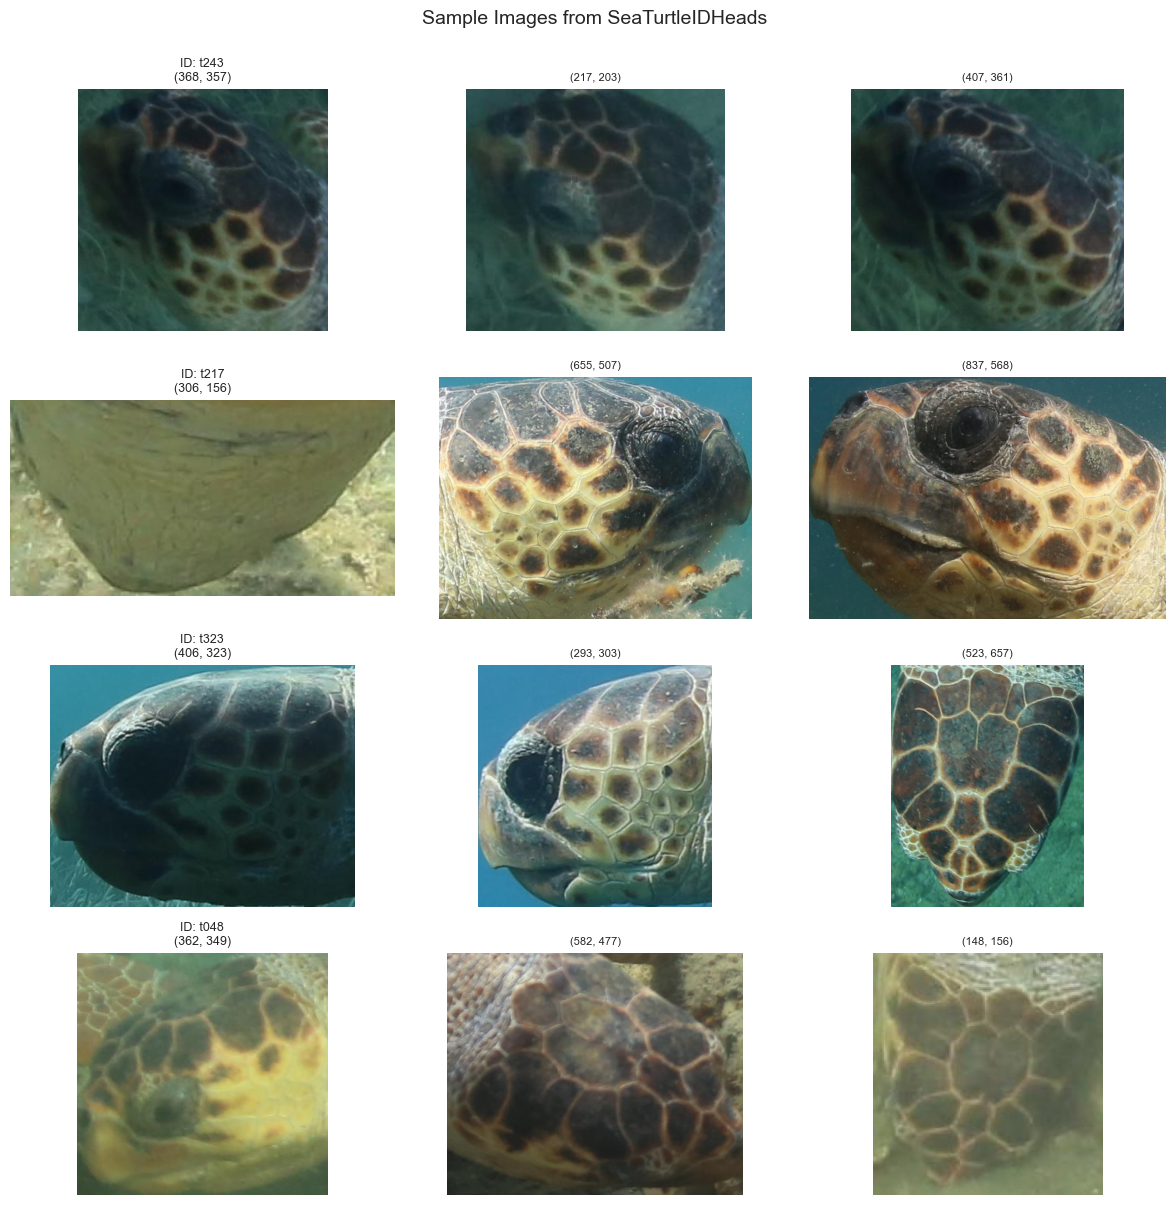

In [21]:
# Visualize sample images from wildlife dataset
try:
    if 'wildlife_ds' in locals() and wildlife_ds is not None and 'dataset_name' in locals() and hasattr(wildlife_ds, 'df'):
        df = wildlife_ds.df
        
        # Sample a few different identities
        if 'identity' in df.columns:
            sample_identities = df['identity'].value_counts().head(4).index
            
            fig, axes = plt.subplots(len(sample_identities), 3, figsize=(12, len(sample_identities) * 3))
            
            for i, identity in enumerate(sample_identities):
                identity_images = df[df['identity'] == identity].head(3)
                
                for j, (_, row) in enumerate(identity_images.iterrows()):
                    # Get image path
                    if 'path' in row:
                        img_path = Path('../data/wildlife_datasets') / dataset_name / row['path']
                    elif 'filepath' in row:
                        img_path = Path(row['filepath'])
                    else:
                        continue
                    
                    if img_path.exists():
                        img = Image.open(img_path)
                        
                        if len(sample_identities) == 1:
                            ax = axes[j]
                        else:
                            ax = axes[i, j]
                        
                        ax.imshow(img)
                        ax.axis('off')
                        if j == 0:
                            ax.set_title(f"ID: {identity}\n{img.size}", fontsize=9)
                        else:
                            ax.set_title(f"{img.size}", fontsize=8)
            
            plt.suptitle(f'Sample Images from {dataset_name}', fontsize=14, y=1.00)
            plt.tight_layout()
            plt.show()
        else:
            print("Identity column not found in dataset")
    else:
        print("Dataset not loaded - run the dataset loading cell below first")
except NameError:
    print("Dataset not loaded - run the dataset loading cell below first")

In [22]:
# Explore the wildlife dataset structure
try:
    if 'wildlife_ds' in locals() and wildlife_ds is not None and 'dataset_name' in locals():
        print(f"Dataset: {dataset_name}")
        print("=" * 60)
        
        # Check available attributes
        print("\n📊 Dataset Statistics:")
        
        # Get dataframe if available
        if hasattr(wildlife_ds, 'df'):
            df = wildlife_ds.df
            print(f"  Total images: {len(df)}")
            
            if 'identity' in df.columns:
                unique_identities = df['identity'].nunique()
                print(f"  Unique identities: {unique_identities}")
                print(f"  Images per identity (avg): {len(df) / unique_identities:.2f}")
            
            print(f"\n📋 Available columns: {df.columns.tolist()}")
            print(f"\n🔍 First few rows:")
            display(df.head())
            
            # Show identity distribution
            if 'identity' in df.columns:
                identity_counts = df['identity'].value_counts()
                print(f"\n📈 Identity Distribution:")
                print(f"  Min images per identity: {identity_counts.min()}")
                print(f"  Max images per identity: {identity_counts.max()}")
                print(f"  Median images per identity: {identity_counts.median():.0f}")
    else:
        print("Dataset not loaded - run the dataset loading cell below first")
except NameError:
    print("Dataset not loaded - run the dataset loading cell below first")

Dataset: SeaTurtleIDHeads

📊 Dataset Statistics:
  Total images: 7582
  Unique identities: 400
  Images per identity (avg): 18.95

📋 Available columns: ['image_id', 'identity', 'path', 'date', 'orientation']

🔍 First few rows:


,image_id,identity,path,date,orientation
0,0,t281,images/t281/ILXxnZwvNh.JPG,2016-07-11,topleft
1,1,t281,images/t281/DjtwgIIURL.JPG,2016-07-11,right
2,2,t281,images/t281/hHfmOdhzDU.JPG,2016-07-11,topleft
3,3,t281,images/t281/gTovpgwOut.JPG,2016-07-11,left
4,4,t281,images/t281/yUETlrBYAp.JPG,2016-07-11,right



📈 Identity Distribution:
  Min images per identity: 1
  Max images per identity: 182
  Median images per identity: 13


### Download and Load a Wildlife Dataset

Let's download a small dataset to see how it works. We'll use **MacaqueFaces** as an example (relatively small dataset of macaque faces).

In [26]:
# Get metadata about specific datasets (without downloading)
from wildlife_datasets import datasets

# Example datasets to explore
example_datasets = ['MacaqueFaces', 'SeaTurtleIDHeads', 'BelugaID', 'GiraffeZebraID', 'CTai', 'BalearicLizardSegmented']

print("Dataset Information:\n")
for dataset_name in example_datasets:
    if hasattr(datasets, dataset_name):
        dataset_class = getattr(datasets, dataset_name)
        
        # Try to get metadata without downloading
        print(f"📁 {dataset_name}")
        print(f"   Class: {dataset_class.__name__}")
        
        # Check if dataset has metadata attributes
        if hasattr(dataset_class, '__doc__') and dataset_class.__doc__:
            doc_lines = dataset_class.__doc__.strip().split('\n')
            if doc_lines:
                print(f"   Description: {doc_lines[0][:80]}...")
        
        print()


Dataset Information:

📁 MacaqueFaces
   Class: MacaqueFaces

📁 SeaTurtleIDHeads
   Class: SeaTurtleIDHeads

📁 BelugaID
   Class: BelugaID

📁 GiraffeZebraID
   Class: GiraffeZebraID

📁 CTai
   Class: CTai

📁 BalearicLizardSegmented
   Class: BalearicLizardSegmented



### Explore Dataset Metadata

Let's look at some interesting datasets that might be useful for training:

In [24]:
# List all available wildlife datasets
from src.data_loading import get_available_wildlife_datasets

available_datasets = get_available_wildlife_datasets()
print(f"Total available datasets: {len(available_datasets)}\n")
print("Available datasets:")
for i, dataset_name in enumerate(sorted(available_datasets), 1):
    print(f"{i:2d}. {dataset_name}")


Total available datasets: 74

Available datasets:
 1. AAUZebraFish
 2. ATRW
 3. AerialCattle2017
 4. AmvrakikosTurtles
 5. AnimalCLEF2025
 6. AnimalCLEF2025_LynxID2025
 7. AnimalCLEF2025_SalamanderID2025
 8. AnimalCLEF2025_SeaTurtleID2022
 9. AnimalCLEF2026
10. AnimalCLEF2026_TexasHornedLizards
11. BalearicLizard
12. BalearicLizardSegmented
13. BelugaID
14. BelugaIDv2
15. BirdIndividualID
16. BirdIndividualIDSegmented
17. BristolGorillas2020
18. CTai
19. CZoo
20. CatIndividualImages
21. CattleMuzzle
22. Chicks4FreeID
23. CoBRAReIdentificationYoungstock
24. CowDataset
25. Cows2021
26. Cows2021v2
27. CzechLynx
28. CzechLynxv2
29. DatasetFactory
30. DogFaceNet
31. DownloadHuggingFace
32. DownloadINaturalist
33. DownloadKaggle
34. DownloadURL
35. Drosophila
36. ELPephants
37. FriesianCattle2015
38. FriesianCattle2015v2
39. FriesianCattle2017
40. GiraffeZebraID
41. Giraffes
42. HappyWhale
43. HolsteinCattleRecognition
44. HumpbackWhaleID
45. HyenaID2022
46. IPanda50
47. LeopardID2022
48. Li

In [ ]:
# [30/01/2026] Added AnimalCLEF2026 (unifications of multiple datasets), BalearicLizards (lizards) and TurtlesOfSMSRC (sea turtles). [18/08/2025] Reached 50 datasets by adding BristolGorillas2020 (primates), CattleMuzzle, CoBRAReIdentificationYoungstock, HolsteinCattleRecognition (cows), CzechLynx (lynxes) and WildRaptorID (eagles).

# BalearicLizardSegmented

## Wildlife Datasets Library

The `wildlife-datasets` package provides access to 50+ wildlife re-identification datasets that can be used for additional training data.

In [25]:
# Initialize variables for wildlife datasets
# This will be populated when you download a dataset below
wildlife_ds = None
dataset_name = None